In [1]:
import numpy as np
import os
import globals as gl
import pickle
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from vis import make_yref
from util import lp_filter

plt.style.use('default')
plt.style.use('dark_background')

Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/


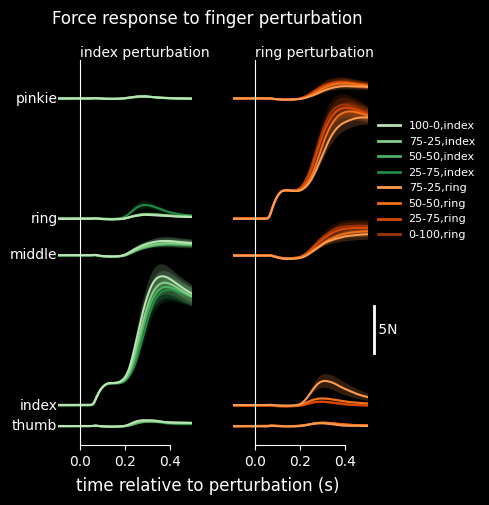

In [2]:
experiment = 'smp2'
npz = np.load(os.path.join(gl.baseDir, experiment, gl.behavDir, 'force.segmented.avg.npz'), allow_pickle=True)
force = npz['data_array']
descr = pd.DataFrame(npz['descriptor'].item())

force = force[descr.GoNogo == 'go']
descr = descr[descr.GoNogo == 'go']

fig, axs = plt.subplots(1, 2, figsize=(4, 5), sharey=True, sharex=True)

tAx = np.linspace(-gl.prestim, gl.poststim, force.shape[-1])

space = [[0, 2, 18, 22, 35], [0, 2, 18, 22, 35]]
for f, finger in enumerate(descr.finger.unique()):
    for s, stimFinger in enumerate(descr.stimFinger.unique()):
        for c, cue in enumerate(descr.cue.unique()):
            force_tmp = force[(descr.cue == cue) & (descr.stimFinger == stimFinger) & (descr.finger == finger)]

            if stimFinger == 'index':
                ax=axs[0]
            else:
                ax=axs[1]

            y = force_tmp.mean(axis=0) + space[s][f]
            yerr = force_tmp.std(axis=0) / np.sqrt(force_tmp.shape[0])

            if ~np.isnan(y).any():
                ax.plot(tAx, y, color=gl.colour_mapping[f'{cue},{stimFinger}'])
                ax.fill_between(tAx, y - yerr, y + yerr, color=gl.colour_mapping[f'{cue},{stimFinger}'], lw=0, alpha=.2)

            if (s == 0) & (c == 1):
                ax.text(-.1, y[0], finger, va='center', ha='right',)

axs[0].set_xlim([-.1, .5])
axs[1].set_xlim([-.1, .5])

axs[0].set_xticks([0, .2, .4])
axs[1].set_xticks([0, .2, .4])

make_yref(axs[1], reference_length=5, pos='right', color='w')

axs[0].spines[['bottom']].set_bounds(0, .4)
axs[1].spines[['bottom']].set_bounds(0, .4)
# axs[0].spines[['bottom']].set_linewidth(2)
# axs[1].spines[['bottom']].set_linewidth(2)
# axs[0].tick_params(width=2)
# axs[1].tick_params(width=2)

axs[0].text(0, ax.get_ylim()[1], 'index perturbation', va='bottom', ha='left')
axs[1].text(0, ax.get_ylim()[1], 'ring perturbation', va='bottom', ha='left')

for ax in axs:
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.axvline(0, ls='-', color='w', lw=.8)
    ax.set_yticks([])

fig.suptitle('Force response to finger perturbation')
fig.supxlabel('time relative to perturbation (s)')

# Create legend entries as colored lines (matching plotted lines)
legend_elements = []
for k,v in gl.colour_mapping.items():
    if 'ring' in k or 'index' in k:
        legend_elements.append(Line2D([0], [0], color=v, lw=2, label=k))

# Add the legend to the figure, outside the right edge
fig.legend(handles=legend_elements,
           loc='lower left',
           fontsize=8,
           bbox_to_anchor=(.9, .5),
           frameon=False)

fig.subplots_adjust(wspace=.3)

plt.show()

index: 0.04400000000000004 ms
ring: 0.052000000000000046 ms


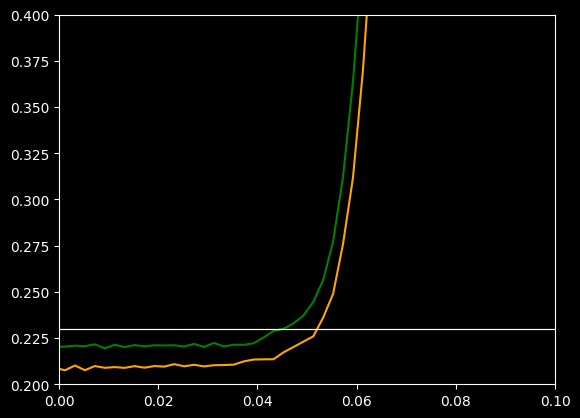

In [3]:
# === Load data ===
experiment = 'smp2'
npz = np.load(os.path.join(gl.baseDir, experiment, gl.behavDir, 'force.segmented.avg.npz'), allow_pickle=True)
force = npz['data_array']
descr = pd.DataFrame(npz['descriptor'].item())

force = force[descr.GoNogo == 'go']
descr = descr[descr.GoNogo == 'go']

thresh = .230

fig, ax = plt.subplots()

tAx = np.linspace(-gl.prestim, gl.poststim, force.shape[-1])

for stimFinger in descr.stimFinger.unique():
    if stimFinger == 'index':
        force_tmp = np.nanmean(force[(descr.stimFinger == stimFinger) & (descr.finger == 'index')], axis=0)
        color = 'green'
    if stimFinger == 'ring':
        force_tmp = np.nanmean(force[(descr.stimFinger == stimFinger) & (descr.finger == 'ring')], axis=0)
        color = 'orange'

    above_thresh = force_tmp > thresh
    latency = np.where(above_thresh==1)[0][0] / 500
    latency = latency - gl.prestim

    print(f'{stimFinger}: {latency} ms')

    ax.plot(tAx, force_tmp, color=color)
    ax.axhline(thresh, ls='-', color='w', lw=.8)
    ax.set_xlim([0, .1])
    ax.set_ylim([.2, .4])

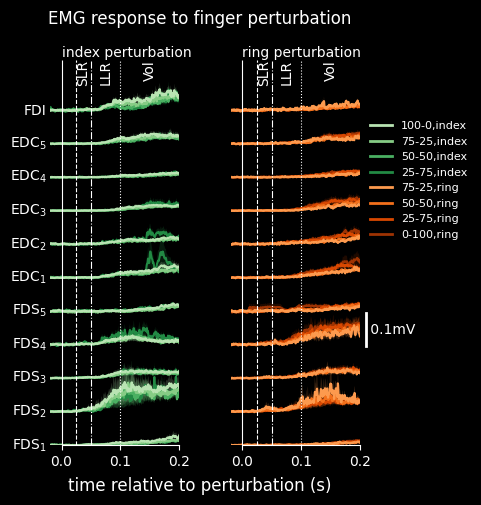

In [10]:
experiment = 'smp0'

f = open(os.path.join(gl.baseDir, experiment, 'emg', 'emg.p'), 'rb')
Dict = pickle.load(f)

# Time axis for each latency
tAx = np.linspace(-1, 2, 6444)

# Set up plot
fig, axs = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(4, 5))

# Vertical lines and associated styles
line_xs = [0, .025, .05, .1]
line_styles = ['-', '--', '-.', ':']
line_labels = ['SLR', 'LLR', 'Vol']

for ch, channel in enumerate(Dict.keys()):
    for c, cue in enumerate(gl.cue_mapping.values()):
        for s, stimFinger in enumerate(gl.stimFinger):

            ax = axs[s]

            data = np.array(Dict[channel])
            y = np.nanmean(data[:, c, s], axis=0) + ch * .1
            yerr = np.nanstd(data[:, c, s], axis=0) / np.sqrt(10)

            if ~np.isnan(y).any():
                ax.plot(tAx, y, color=gl.colour_mapping[f'{cue},{stimFinger}'])
                ax.fill_between(tAx, y- yerr, y + yerr,
                                color=gl.colour_mapping[f'{cue},{stimFinger}'], lw=0, alpha=.2)

            if (s == 0) & (c == 1):
                label = (f'FDS$_{{{ch+1}}}$' if ch < 5 else
                         f'EDC$_{{{ch-4}}}$' if (ch >= 5) & (ch < 10) else
                         'FDI' if ch == 10 else '')
                ax.text(-.025, y[0], label, va='center', ha='right',)

# Draw vertical lines
for ax in axs:
    ax.set_ylim((0, 1.15))
    for x, style in zip(line_xs, line_styles):
        ax.vlines(x, ymin=0, ymax=ax.get_ylim()[1], linestyles=style, color='w', lw=.8)

    ax.set_xlim([-.02, .2])

#     ax.set_ylim([0, 1.15])
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.spines['bottom'].set_visible(True)

    # Remove y-ticks and labels
    ax.set_yticks([])
    ax.set_yticklabels([])

    ax.spines['bottom'].set_bounds([0, .2])
    # ax.spines['bottom'].set_linewidth(2)
    # ax.tick_params(width=2)
    ax.set_xticks([0, .1, .2])
    # set_spines_and_ticks_width(ax, spine_width=1.5, spine_sides=('bottom',), tick_width=1.5, axes=('x',), which='both')

    # Place text labels between key vertical lines
    xlims = ax.get_xlim()
    text_positions = [
        (.025 + .05) / 2,          # "SLR"
        (.05 + .1) / 2,            # "LLR"
        (.1 + xlims[1]) / 2        # "Vol"
    ]
    for label, xpos in zip(line_labels, text_positions):
        ax.text(xpos, ax.get_ylim()[1], label, ha='center', va='top',  rotation=90,)
#
# # Global labels and layout
fig.supxlabel('time relative to perturbation (s)')
make_yref(axs[1], reference_length=.1, pos='right', unit='mV', color='w')

# Create legend entries as colored lines (matching plotted lines)
legend_elements = []
for k,v in gl.colour_mapping.items():
    if 'ring' in k or 'index' in k:
        legend_elements.append(Line2D([0], [0], color=v, lw=2, label=k))

# Add the legend to the figure, outside the right edge
fig.legend(handles=legend_elements,
           loc='lower left',
           bbox_to_anchor=(.9, .5),
           fontsize=8,
           frameon=False)

axs[0].text(0, ax.get_ylim()[1], 'index perturbation', va='bottom', ha='left')
axs[1].text(0, ax.get_ylim()[1], 'ring perturbation', va='bottom', ha='left')

fig.suptitle('EMG response to finger perturbation',)
fig.subplots_adjust(wspace=.4)
plt.show()


AxisError: axis 1 is out of bounds for array of dimension 1

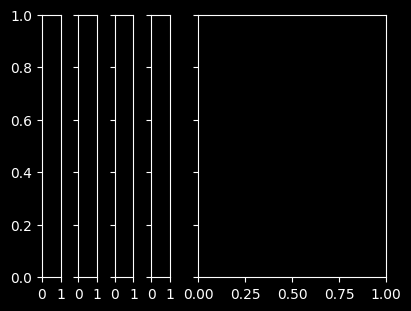

In [5]:
# experiment = 'smp0'
# snS = [100, 101, 102, 104, 105, 106, 107, 108, 109, 110]
#
# wins = [(-.1, 0.0), (.025, .05), (.05, .1), (.1, .5)]
# epochs = ['Pre', 'SLR', 'LLR', 'Vol']
# onset = 2148
#
# pc = {
#     '100%-0%,index': [],
#     '75%-25%,index': [],
#     '50%-50%,index': [],
#     '25%-75%,index': [],
#     '75%-25%,ring': [],
#     '50%-50%,ring': [],
#     '25%-75%,ring': [],
#     '0%-100%,ring': [],
# }
#
# fs = 2148
# onset = int(1 * fs)
# start = onset - int(.02 * fs)
# end = onset + int(.5 * fs)
#
# N = 10
#
# for sn in snS:
#     pc_tmp = np.load(os.path.join(gl.baseDir, experiment, 'emg', f'subj{sn}', 'pcs.npy'))
#     dat = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}.dat'), sep='\t')
#
#     dat.stimFinger = dat.stimFinger.map(gl.stimFinger_mapping)
#     dat.cue = dat.cue.map(gl.cue_mapping)
#
#     for cue in dat.cue.unique():
#         for stimFinger in dat.stimFinger.unique():
#             if f'{cue},{stimFinger}' in pc.keys():
#                 pc[f'{cue},{stimFinger}'].append(pc_tmp[(dat.cue == cue) & (dat.stimFinger == stimFinger)])
#
# fig, axs = plt.subplots(1, 5, gridspec_kw={'width_ratios': [.5, .5, .5, .5, 5]},  sharey=True, figsize=(4, 3), constrained_layout=True)
#
# for k, v in pc.items():
#     pc[k] = np.array(v).mean(axis=1)
#     pc_avg = pc[k].mean(axis=0)
#     pc_avg_filt = lp_filter(pc_avg, 10, fs,)
#     axs[-1].plot(pc_avg_filt[0, start:end], pc_avg_filt[1, start:end], color=gl.colour_mapping[k], alpha=.5, lw=2)
#
#     for w, win in enumerate(wins):
#         pc_avg_w = pc[k][..., int(onset + win[0] * fs):int(onset + win[1] * fs)].mean(axis=(0, -1))
#         pc_avg_err = pc[k][..., int(onset + win[0] * fs):int(onset + win[1] * fs)].mean(axis=-1).std(axis=0) / np.sqrt(N)
#
#         axs[w].scatter(0, pc_avg_w[1], color=gl.colour_mapping[k])
#         axs[w].set_xticks([])
#         axs[w].set_title(epochs[w], fontsize=12, va='center', rotation=90)
#
#         if w>0:
#             axs[w].spines[['top', 'right', 'bottom', 'left']].set_visible(False)
#             axs[w].tick_params(width=0)
#         else:
#             axs[w].spines[['top', 'right', 'bottom', ]].set_visible(False)
#             axs[w].spines[['left', ]].set_bounds(-.5, 1)
#             # axs[w].spines[['left', ]].set_linewidth(2)
#             axs[w].tick_params(width=1)
#
# axs[-1].set_xlim([-1, 3.5])
# axs[-1].set_ylim([-.75, 1.1])
#
# axs[-1].spines[['top', 'right', 'left', ]].set_visible(False)
# axs[-1].tick_params(width=1)
# axs[-1].tick_params(axis='y', width=0)
# axs[-1].spines[['bottom', ]].set_bounds(-1, 3)
# # axs[-1].spines[['bottom', ]].set_linewidth(2)
#
# axs[-1].set_xlabel('PC1')
# axs[0].set_ylabel('PC2')
#
# fig.suptitle('EMG trajectories')
#
# plt.show()
